In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv('Teen_Mental_Health_Dataset.csv')
print(df.shape)
print(df.head())
print(df.columns.tolist())

(1200, 13)
   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      low             2       

In [4]:
#eksik değer kontrolü 
print('eksik değerler!')
print(df.isnull().sum())

#temel istatistikler
print('\nGenel istatistikler')
print(df.describe().round(2))

eksik değerler!
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

Genel istatistikler
           age  daily_social_media_hours  sleep_hours  \
count  1200.00                   1200.00      1200.00   
mean     15.93                      4.54         6.45   
std       2.02                      2.03         1.44   
min      13.00                      1.00         4.00   
25%      14.00                      2.80         5.20   
50%      16.00                      4.50         6.50   
75%      18.00                      6.30         7.60   
max      19.00                      8.00         9.00   

       screen_time_before_sleep  academic_perf

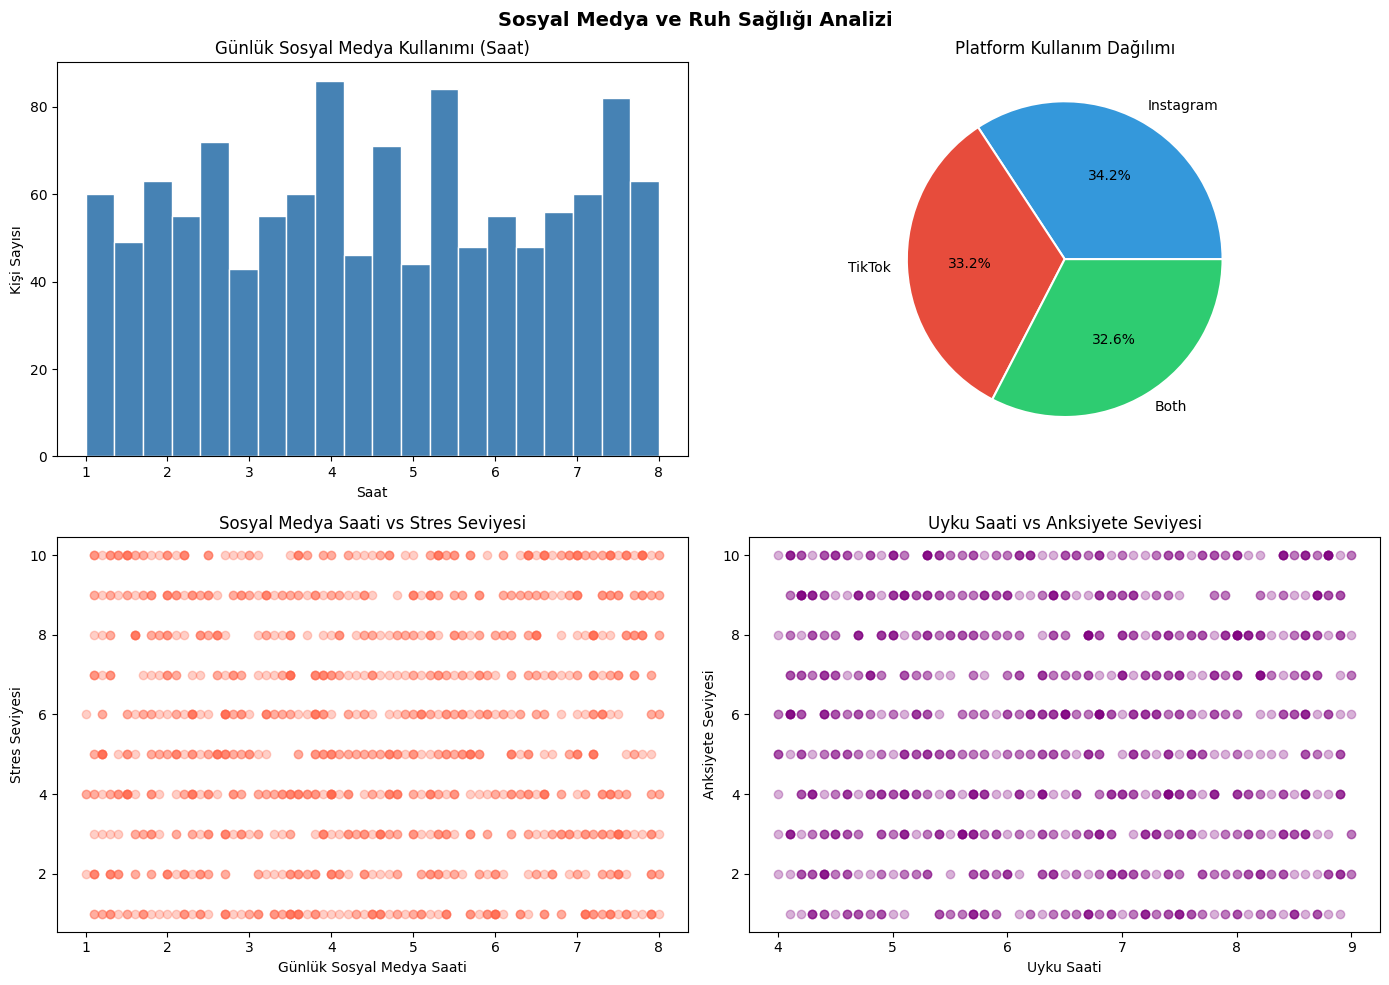

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Grafik 1 — Günlük sosyal medya kullanımı dağılımı
axes[0,0].hist(df["daily_social_media_hours"], bins=20, color="steelblue", edgecolor="white")
axes[0,0].set_title("Günlük Sosyal Medya Kullanımı (Saat)")
axes[0,0].set_xlabel("Saat")
axes[0,0].set_ylabel("Kişi Sayısı")

# Grafik 2 — Platform kullanım dağılımı
platform_counts = df["platform_usage"].value_counts()
axes[0,1].pie(platform_counts, labels=platform_counts.index, autopct="%1.1f%%",
              colors=["#3498db","#e74c3c","#2ecc71","#f39c12","#9b59b6"],
              wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[0,1].set_title("Platform Kullanım Dağılımı")

# Grafik 3 — Sosyal medya saati vs stres seviyesi
axes[1,0].scatter(df["daily_social_media_hours"], df["stress_level"],
                  alpha=0.3, color="tomato")
axes[1,0].set_title("Sosyal Medya Saati vs Stres Seviyesi")
axes[1,0].set_xlabel("Günlük Sosyal Medya Saati")
axes[1,0].set_ylabel("Stres Seviyesi")

# Grafik 4 — Uyku saati vs anksiyete
axes[1,1].scatter(df["sleep_hours"], df["anxiety_level"],
                  alpha=0.3, color="purple")
axes[1,1].set_title("Uyku Saati vs Anksiyete Seviyesi")
axes[1,1].set_xlabel("Uyku Saati")
axes[1,1].set_ylabel("Anksiyete Seviyesi")

plt.suptitle("Sosyal Medya ve Ruh Sağlığı Analizi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("sosyal_medya_analiz.png", dpi=150)
plt.show()

C:\Users\lio\AppData\Local\Temp\ipykernel_1332\225759993.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([dep_0, dep_1], labels=["Depresyon Yok", "Depresyon Var"],


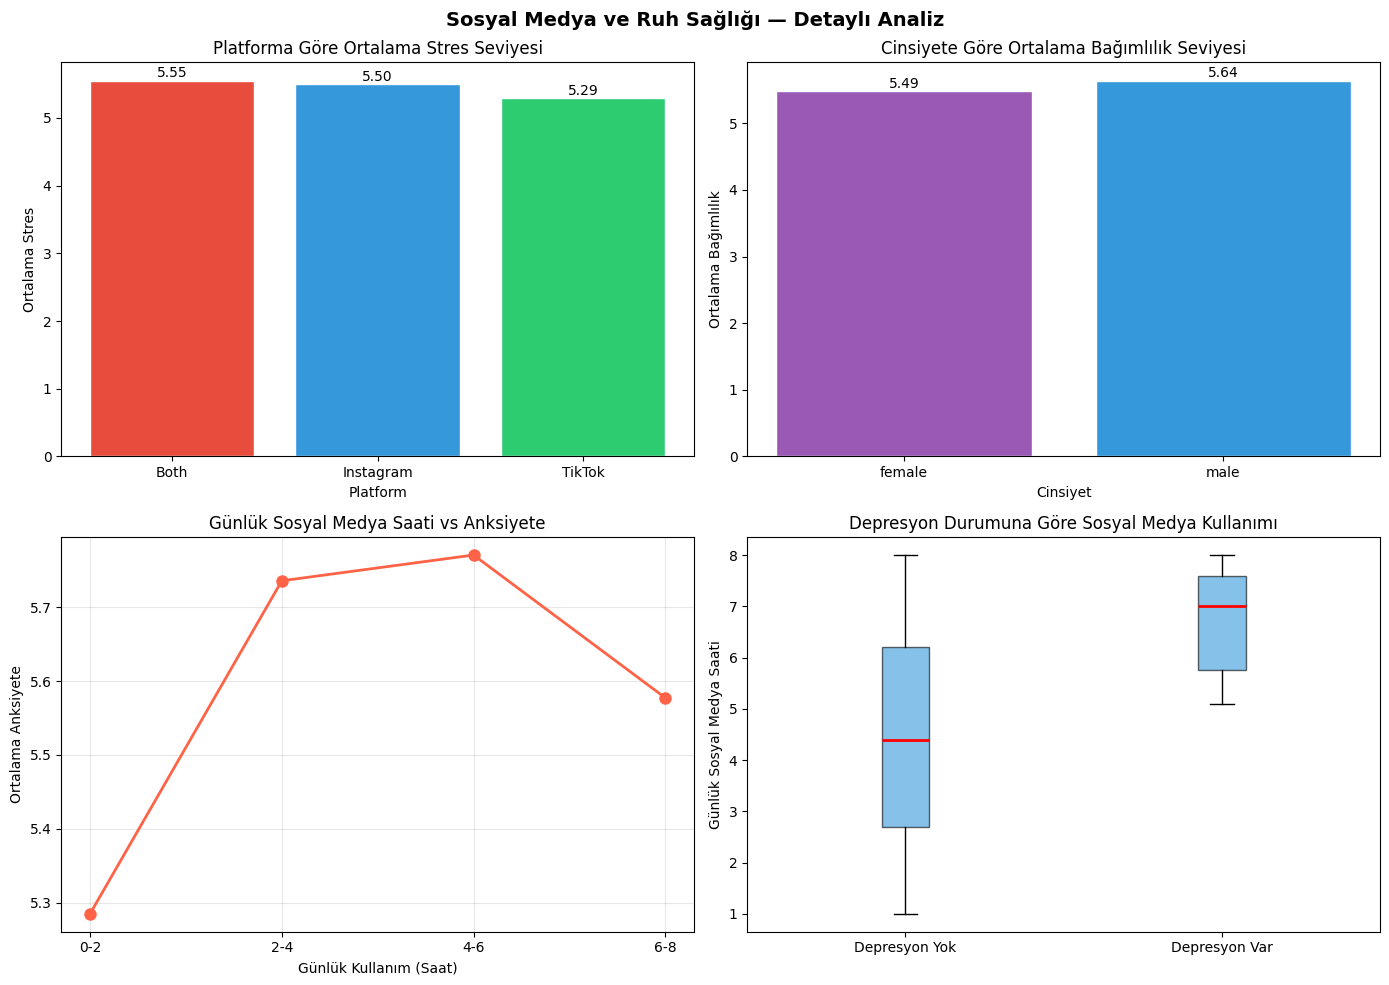

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Grafik 1 — Platforma göre ortalama stres seviyesi
platform_stres = df.groupby("platform_usage")["stress_level"].mean().sort_values(ascending=False)
axes[0,0].bar(platform_stres.index, platform_stres.values, 
              color=["#e74c3c","#3498db","#2ecc71"], edgecolor="white")
axes[0,0].set_title("Platforma Göre Ortalama Stres Seviyesi")
axes[0,0].set_xlabel("Platform")
axes[0,0].set_ylabel("Ortalama Stres")
for i, v in enumerate(platform_stres.values):
    axes[0,0].text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=10)

# Grafik 2 — Cinsiyete göre bağımlılık seviyesi
cinsiyet_bagimlilik = df.groupby("gender")["addiction_level"].mean()
axes[0,1].bar(cinsiyet_bagimlilik.index, cinsiyet_bagimlilik.values,
              color=["#9b59b6","#3498db"], edgecolor="white")
axes[0,1].set_title("Cinsiyete Göre Ortalama Bağımlılık Seviyesi")
axes[0,1].set_xlabel("Cinsiyet")
axes[0,1].set_ylabel("Ortalama Bağımlılık")
for i, v in enumerate(cinsiyet_bagimlilik.values):
    axes[0,1].text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=10)

# Grafik 3 — Sosyal medya saatine göre ortalama anksiyete
df["saat_grubu"] = pd.cut(df["daily_social_media_hours"], 
                           bins=[0,2,4,6,8,10], 
                           labels=["0-2","2-4","4-6","6-8","8+"])
saat_anksiyete = df.groupby("saat_grubu", observed=True)["anxiety_level"].mean()
axes[1,0].plot(saat_anksiyete.index, saat_anksiyete.values, 
               marker="o", color="tomato", linewidth=2, markersize=8)
axes[1,0].set_title("Günlük Sosyal Medya Saati vs Anksiyete")
axes[1,0].set_xlabel("Günlük Kullanım (Saat)")
axes[1,0].set_ylabel("Ortalama Anksiyete")
axes[1,0].grid(True, alpha=0.3)

# Grafik 4 — Depresyon olan ve olmayanlarda sosyal medya kullanımı
dep_0 = df[df["depression_label"] == 0]["daily_social_media_hours"]
dep_1 = df[df["depression_label"] == 1]["daily_social_media_hours"]
axes[1,1].boxplot([dep_0, dep_1], labels=["Depresyon Yok", "Depresyon Var"],
                  patch_artist=True,
                  boxprops=dict(facecolor="#3498db", alpha=0.6),
                  medianprops=dict(color="red", linewidth=2))
axes[1,1].set_title("Depresyon Durumuna Göre Sosyal Medya Kullanımı")
axes[1,1].set_ylabel("Günlük Sosyal Medya Saati")

plt.suptitle("Sosyal Medya ve Ruh Sağlığı — Detaylı Analiz", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("sosyal_medya_detay.png", dpi=150)
plt.show()

In [8]:
print("=" * 50)
print("SOSYAL MEDYA VE RUH SAĞLIĞI — BULGULAR")
print("=" * 50)

print(f"""
1. PLATFORM VE STRES:
   - En stresli platform: Both (5.55)
   - En az stresli: TikTok (5.29)
   - Fark çok küçük, platform türü stresi belirlemez.

2. CİNSİYET VE BAĞIMLILIK:
   - Erkek: {df[df['gender']=='male']['addiction_level'].mean():.2f}
   - Kadın: {df[df['gender']=='female']['addiction_level'].mean():.2f}
   - Erkekler biraz daha bağımlı görünüyor.

3. KULLANIM SÜRESİ VE ANKSİYETE:
   - 0-2 saat kullananlar: en düşük anksiyete
   - 4-6 saat kullanım: anksiyete zirveye çıkıyor
   - Az kullan = daha düşük anksiyete

4. DEPRESYON VE SOSYAL MEDYA:
   - Depresyon YOK: günlük ortalama {dep_0.mean():.1f} saat
   - Depresyon VAR: günlük ortalama {dep_1.mean():.1f} saat
   - Depresyonu olanlar çok daha fazla sosyal medya kullanıyor!
""")

SOSYAL MEDYA VE RUH SAĞLIĞI — BULGULAR

1. PLATFORM VE STRES:
   - En stresli platform: Both (5.55)
   - En az stresli: TikTok (5.29)
   - Fark çok küçük, platform türü stresi belirlemez.

2. CİNSİYET VE BAĞIMLILIK:
   - Erkek: 5.64
   - Kadın: 5.49
   - Erkekler biraz daha bağımlı görünüyor.

3. KULLANIM SÜRESİ VE ANKSİYETE:
   - 0-2 saat kullananlar: en düşük anksiyete
   - 4-6 saat kullanım: anksiyete zirveye çıkıyor
   - Az kullan = daha düşük anksiyete

4. DEPRESYON VE SOSYAL MEDYA:
   - Depresyon YOK: günlük ortalama 4.5 saat
   - Depresyon VAR: günlük ortalama 6.7 saat
   - Depresyonu olanlar çok daha fazla sosyal medya kullanıyor!



In [10]:
from scipy import stats

print("=" * 55)
print("İSTATİSTİKSEL ANALİZ RAPORU")
print("=" * 55)

# 1. Korelasyon analizi
korelas1, p1 = stats.pearsonr(df["daily_social_media_hours"], df["stress_level"])
korelas2, p2 = stats.pearsonr(df["daily_social_media_hours"], df["anxiety_level"])
korelas3, p3 = stats.pearsonr(df["daily_social_media_hours"], df["addiction_level"])
korelas4, p4 = stats.pearsonr(df["sleep_hours"], df["stress_level"])

print(f"""
1. PEARSON KORELASYON ANALİZİ:
   Sosyal Medya ↔ Stres:      r={korelas1:.3f}, p={p1:.4f}
   Sosyal Medya ↔ Anksiyete:  r={korelas2:.3f}, p={p2:.4f}
   Sosyal Medya ↔ Bağımlılık: r={korelas3:.3f}, p={p3:.4f}
   Uyku Saati   ↔ Stres:      r={korelas4:.3f}, p={p4:.4f}
""")

# 2. Bağımsız örneklem t-testi (depresyon var vs yok)
t_stat, p_ttest = stats.ttest_ind(dep_1, dep_0)
print(f"""
2. BAĞIMSIZ ÖRNEKLEM T-TESTİ:
   Depresyon VAR vs YOK — Sosyal Medya Kullanımı
   t istatistiği: {t_stat:.3f}
   p değeri:      {p_ttest:.4f}
   Sonuç: {"İstatistiksel olarak ANLAMLI fark var (p<0.05)" if p_ttest < 0.05 else "Anlamlı fark YOK"}
""")

# 3. ANOVA — platforma göre stres farkı var mı?
gruplar = [df[df["platform_usage"] == p]["stress_level"] for p in df["platform_usage"].unique()]
f_stat, p_anova = stats.f_oneway(*gruplar)
print(f"""
3. TEK YÖNLÜ ANOVA:
   Platform türüne göre stres seviyesi farkı
   F istatistiği: {f_stat:.3f}
   p değeri:      {p_anova:.4f}
   Sonuç: {"Platformlar arasında ANLAMLI fark var (p<0.05)" if p_anova < 0.05 else "Platformlar arasında anlamlı fark YOK"}
""")

# 4. Etki büyüklüğü (Cohen's d) — depresyon grupları
def cohens_d(g1, g2):
    return (g1.mean() - g2.mean()) / ((g1.std() + g2.std()) / 2)

d = cohens_d(dep_1, dep_0)
print(f"""
4. ETKİ BÜYÜKLÜĞܠ(Cohen's d):
   Depresyon grupları arası sosyal medya kullanımı
   Cohen's d: {d:.3f}
   Yorum: {"Büyük etki" if abs(d)>0.8 else "Orta etki" if abs(d)>0.5 else "Küçük etki"}
""")

print("=" * 55)
print("GENEL YORUM:")
print("""
- Sosyal medya kullanım süresi ile stres, anksiyete
  ve bağımlılık arasındaki korelasyon istatistiksel
  olarak anlamlıysa günlük kullanımı kısıtlamak
  ruh sağlığını olumlu etkileyebilir.
- Depresyon grubundaki bireyler belirgin şekilde
  daha fazla sosyal medya kullanmaktadır.
- Platform türünün stresi belirlemediği görülmüş,
  asıl belirleyici faktörün kullanım SÜRESİ olduğu
  anlaşılmaktadır.
""")

ModuleNotFoundError: No module named 'scipy'